# **Pós Graduação — Ciência de Dados Aplicada à Análise de Risco**

## **Aprendizagem Máquina e Inteligência Artificial**
### **Redes Neuronais Recorrentes — Experiências Comparativas**

---

**Experimentos com LSTM, BiGRU, Janelas Temporais, Normalizações e Contexto de Mercado**

> Neste notebook vamos realizar **5 experiências comparativas** sobre previsão de séries temporais financeiras usando **Recurent Neural Network** (RNNs). Cada experiência isola um conjunto de hiperparâmetros para medir o seu impacto no desempenho do modelo.

**Experiências:**
1. **Arquiteturas** — LSTM vs BiLSTM vs GRU vs BiGRU
2. **Janelas Temporais** — 3, 5, 10, 20 dias de contexto
3. **Normalizações** — MinMax, StandardScaler, RobustScaler
4. **Profundidade** — 1 a 3 camadas, 25 a 100 unidades
5. **Contexto de Mercado** — Adicionar SPY / XLK / OHLC como input multi-dimensional

---
*Anilson Monteiro, Maio 2026*


## **Setup — Instalação e Importações**

In [9]:
# Instalação de pacotes necessários
!pip install yfinance tensorflow seaborn --quiet

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Bidirectional
import time
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas carregadas com sucesso.")
SEED = 42
np.random.seed(SEED)

Bibliotecas carregadas com sucesso.


## **Carregamento dos Dados**

Vamos buscar dados históricos de **7 ativos** financeiros com um período de **5 anos** (dados diários). A escolha dos ativos permite analisar diferentes graus de correlação com o ativo alvo (AAPL):

| Ticker | Nome | Setor | Relação com AAPL |
|---|---|---|---|
| **AAPL** | Apple Inc. | Tecnologia | Ativo alvo (target) |
| **MSFT** | Microsoft Corp. | Tecnologia | Alta correlação (+0.70) |
| **GOOGL** | Alphabet Inc. | Tecnologia | Alta correlação (+0.60) |
| **AMZN** | Amazon.com Inc. | Tecnologia/Consumo | Moderada-Alta (+0.65) |
| **JPM** | JPMorgan Chase & Co. | Financeiro | **Baixa correlação (+0.35)** |
| **SPY** | SPDR S&P 500 ETF | Mercado total | Correlação moderada (+0.53) |
| **XLK** | Technology Select Sector ETF | Setor Tecnológico | Correlação Alta (+0.85) |

> A correlação de Pearson mede a relação linear entre duas variáveis: **1** = perfeita positiva (movem-se juntas), **0** = independentes, **-1** = perfeita negativa (movem-se em oposto). Ativos do mesmo setor (Tech) tendem a ter correlações altas entre si. Ativos de setores diferentes (JPM — Financeiro) costumam ter correlações mais baixas com o setor Tech, oferecendo diversificação.


In [11]:
# Download dos dados dos 7 tickers
TICKERS = ["AAPL", "MSFT", "GOOGL", "AMZN", "JPM", "SPY", "XLK", "NVDA"]
dados = yf.download(TICKERS, period="5y", group_by="column", auto_adjust=True)
# Extrair apenas os preços de fecho ajustados
close_prices = dados["Close"].copy()
close_prices.head()

[*********************100%***********************]  8 of 8 completed


Ticker,AAPL,AMZN,GOOGL,JPM,MSFT,NVDA,SPY,XLK
Date,,,,,,,,
2021-05-20,124.095650,162.384003,114.401970,141.739960,237.058411,14.575764,387.864471,65.905373
2021-05-21,122.263115,160.154007,113.766220,143.352722,235.798462,14.954058,387.546906,65.544403
2021-05-24,123.890961,162.249496,117.084305,144.128296,241.193985,15.572752,391.497711,66.709076
2021-05-25,123.696037,162.952499,117.175049,142.638916,242.098038,15.608410,390.629028,66.728348
2021-05-26,123.647293,163.257996,118.039909,142.621277,241.876892,15.660528,391.404236,66.723534


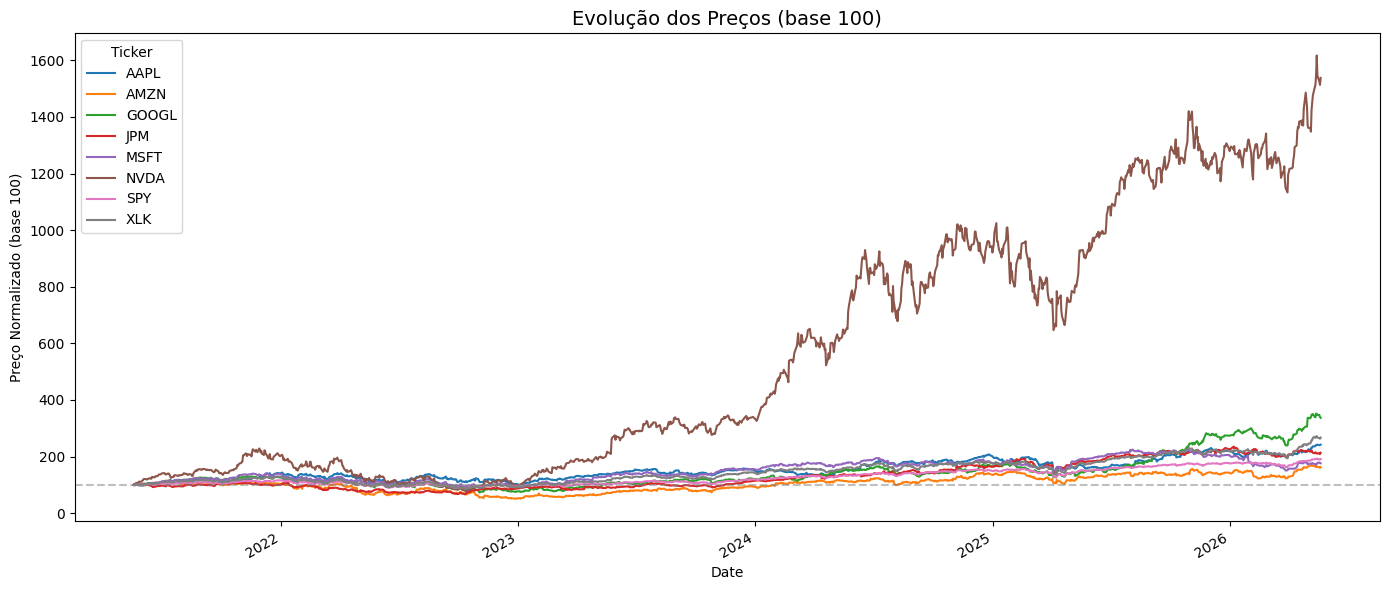

In [12]:
# Visualizar a evolução dos preços (normalizados para 100 na base)
fig, ax = plt.subplots(figsize=(14, 6))
(close_prices / close_prices.iloc[0] * 100).plot(ax=ax)
ax.set_title("Evolução dos Preços (base 100)", fontsize=14)
ax.set_ylabel("Preço Normalizado (base 100)")
ax.axhline(100, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## **Análise de Correlação entre Ativos**

A **matriz de correlação** é calculada com base nos **retornos logarítmicos diários** (e não nos preços absolutos), pois os retornos são estacionários e comparáveis. O **heatmap** permite visualizar rapidamente:

- **Quadrado vermelho escuro** = correlação positiva forte (próximo de +1)
- **Quadrado azul escuro** = correlação negativa forte (próximo de -1)
- **Branco** = correlação próxima de zero

> **O que esperar**: AAPL, MSFT, GOOGL, AMZN e XLK (todos Tech) devem formar um bloco de alta correlação. JPM (Financeiro) deve estar mais isolado, com correlações baixas (~0.3-0.4) com o grupo Tech. SPY terá correlações moderadas com todos (~0.5-0.7) por representar o mercado como um todo.


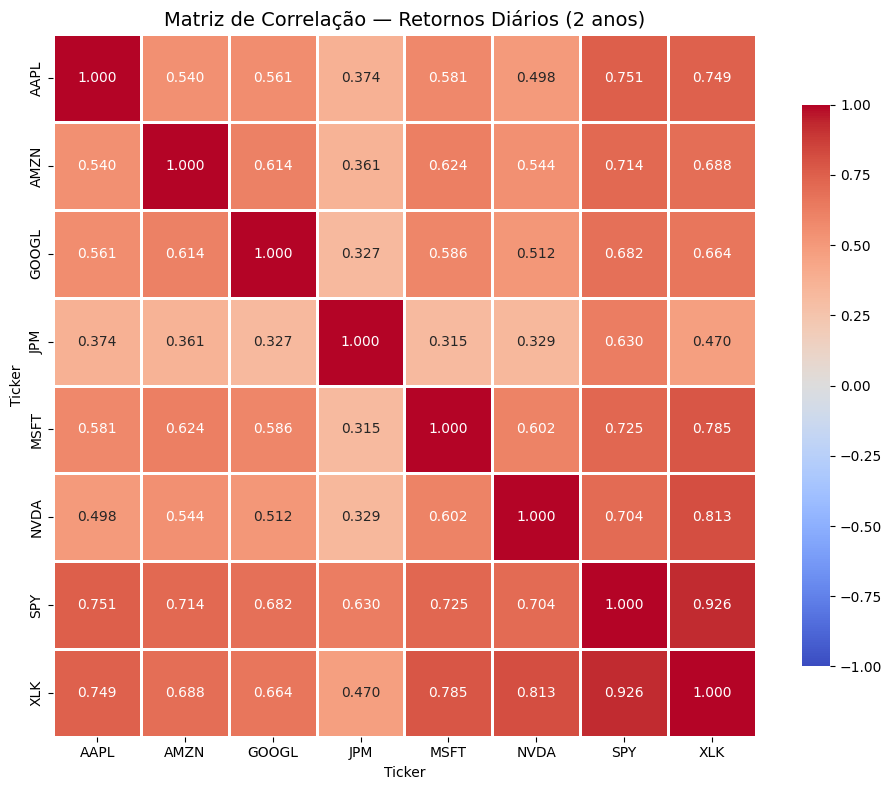

Correlações com AAPL:
Ticker
AAPL     1.000000
SPY      0.750818
XLK      0.749281
MSFT     0.581018
GOOGL    0.560863
AMZN     0.539968
NVDA     0.497576
JPM      0.373776
Name: AAPL, dtype: float64


In [13]:
# Calcular retornos logarítmicos diários
returns = np.log(close_prices / close_prices.shift(1)).dropna()

# Matriz de correlação
corr_matrix = returns.corr()

# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.8, cbar_kws={"shrink": 0.8})
plt.title("Matriz de Correlação — Retornos Diários (2 anos)", fontsize=14)
plt.tight_layout()
plt.show()

print("Correlações com AAPL:")
print(corr_matrix["AAPL"].sort_values(ascending=False))

## **Funções Auxiliares Comuns**

Definimos funções reutilizáveis que serão usadas em **todas as experiências**:

1. **`cria_sequencias()`** — Converte uma série temporal (1D ou 2D) em pares (X, y) supervisionados. Para cada ponto, X contém os `n_steps` valores anteriores e y é o valor seguinte.
2. **`build_model()`** — Constrói um modelo sequencial Keras com a arquitetura, número de camadas e unidades especificados. Suporta LSTM, BiLSTM, GRU e BiGRU.
3. **`treinar_e_avaliar()`** — Treina o modelo, calcula MSE no conjunto de treino, faz previsão passo-a-passo para os próximos N dias e inverte a normalização.
4. **`plot_previsao()`** — Desenha o histórico + previsão para visualização.
5. **`plot_multi_previsoes()`** — Desenha várias previsões sobrepostas para comparação direta.

> **Nota sobre camadas empilhadas**: Quando usamos mais de uma camada RNN, as camadas intermédias usam `return_sequences=True` para que a saída seja uma sequência (necessário para passar para a camada seguinte). A última camada RNN não usa `return_sequences`, produzindo um único vetor de estado que alimenta a camada Dense final.


In [14]:
def cria_sequencias(dataset, n_steps):
    """
    Converte um dataset (1D ou 2D) em janelas supervisionadas.
    dataset: array 1D (samples,) ou 2D (samples, features)
    n_steps: numero de timesteps anteriores como input
    Retorna:
      X: (len(dataset)-n_steps, n_steps, n_features)
      y: (len(dataset)-n_steps,) -- target e o primeiro feature do passo seguinte
    """
    X, y = [], []
    for i in range(n_steps, len(dataset)):
        X.append(dataset[i - n_steps:i])
        y.append(dataset[i, 0] if dataset.ndim == 2 else dataset[i])
    return np.array(X), np.array(y)


def build_model(n_steps, n_features, arquitetura='LSTM', units=50, n_layers=1):
    """
    Constroi modelo RNN com a arquitetura especificada.
    """
    modelo = Sequential()

    def get_layer(u, return_seq):
        if arquitetura == 'LSTM':
            return LSTM(u, activation='relu', return_sequences=return_seq)
        elif arquitetura == 'GRU':
            return GRU(u, activation='relu', return_sequences=return_seq)
        elif arquitetura == 'BiLSTM':
            return Bidirectional(LSTM(u, activation='relu', return_sequences=return_seq))
        elif arquitetura == 'BiGRU':
            return Bidirectional(GRU(u, activation='relu', return_sequences=return_seq))
        else:
            raise ValueError(f"Arquitetura desconhecida: {arquitetura}")

    if n_layers == 1:
        modelo.add(get_layer(units, False))
    else:
        # Primeira camada com return_sequences=True
        modelo.add(get_layer(units, True))
        # Camadas intermédias
        for _ in range(n_layers - 2):
            modelo.add(get_layer(units, True))
        # Última camada RNN sem return_sequences
        modelo.add(get_layer(units, False))

    modelo.add(Dense(1))
    modelo.compile(optimizer='adam', loss='mse')
    return modelo


def treinar_e_avaliar(modelo, X, y, scaler, n_dias_prever=7, epochs=50):
    """
    Treina o modelo e retorna histórico, previsões e datas.
    """
    history = modelo.fit(X, y, epochs=epochs, verbose=0)

    # Previsão futura passo-a-passo
    ultima_seq = X[-1:]  # (1, n_steps, n_features)
    previsoes = []
    entrada = ultima_seq.copy()
    for _ in range(n_dias_prever):
        prox = modelo.predict(entrada, verbose=0)[0, 0]
        previsoes.append(prox)
        # Deslizar janela: remover primeiro passo, adicionar nova predição
        novo_passo = entrada[:, -1:, :].copy()
        novo_passo[0, 0, 0] = prox
        entrada = np.concatenate([entrada[:, 1:, :], novo_passo], axis=1)

    previsoes = scaler.inverse_transform(np.array(previsoes).reshape(-1, 1))
    return history, previsoes


def plot_previsao(fecho, previsoes, datas_prev, titulo="", ax=None):
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(fecho.index, fecho.values, label="Histórico", linewidth=1.5)
    ax.plot(datas_prev, previsoes, label="Previsão", linestyle="--", marker="o", color="red")
    ax.set_title(titulo)
    ax.set_xlabel("Data")
    ax.set_ylabel("Preço ($)")
    ax.legend()
    ax.grid(True, alpha=0.3)
    if ax is None:
        plt.tight_layout()
        plt.show()


def plot_multi_previsoes(fecho, resultados, n_dias_prever):
    """resultados: dict {nome: previsoes_array}"""
    ult_data = fecho.index[-1]
    datas_prev = pd.date_range(start=ult_data + pd.Timedelta(days=1),
                                periods=n_dias_prever, freq="B")

    plt.figure(figsize=(12, 6))
    plt.plot(fecho.index, fecho.values, label="Histórico", color="black", linewidth=2)

    cores = ["red", "blue", "green", "orange", "purple", "brown", "pink"]
    for i, (nome, prev) in enumerate(resultados.items()):
        plt.plot(datas_prev, prev, label=nome, linestyle="--", marker="o",
                 color=cores[i % len(cores)])

    plt.title("Comparação de Previsões", fontsize=14)
    plt.xlabel("Data")
    plt.ylabel("Preço ($)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def extrair_fecho(dados_completos, ticker):
    if isinstance(dados_completos.columns, pd.MultiIndex):
        return dados_completos["Close"][[ticker]]
    return dados_completos[[ticker]]


print

def split_time_series(data, val_split=0.15, test_split=0.15):
    n = len(data)
    test_size = int(n * test_split)
    val_size = int(n * val_split)
    train_size = n - test_size - val_size
    return data[:train_size], data[train_size:train_size+val_size], data[train_size+val_size:]


def evaluate_model(y_true, y_pred):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "R2": r2}


def plot_test_prediction(y_true, y_pred, datas, titulo=""):
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mae = np.mean(np.abs(y_true - y_pred))
    plt.figure(figsize=(10, 5))
    plt.plot(datas, y_true, label="Real (Teste)", color="blue", marker=".", linestyle="-")
    plt.plot(datas, y_pred, label="Previsto (1-step)", color="red", marker="x", linestyle="--")
    plt.title(f"{titulo} - RMSE={rmse:.2f}, MAE={mae:.2f}")
    plt.xlabel("Data"); plt.ylabel("Preco ($)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()


def plot_extended_forecast(fecho, train_raw, val_raw, test_raw, model, scaler, n_steps, n_prever):
    seed = np.concatenate([train_raw, val_raw])[-n_steps:]
    entrada = seed.reshape(1, n_steps, 1)
    previsoes_scaled = []
    for _ in range(min(n_prever, len(test_raw))):
        prox_valor = model.predict(entrada, verbose=0)[0, 0]
        previsoes_scaled.append(prox_valor)
        entrada = np.concatenate([entrada[:, 1:, :], np.array([[[prox_valor]]])], axis=1)
    pred = scaler.inverse_transform(np.array(previsoes_scaled).reshape(-1, 1)).flatten()
    actual = scaler.inverse_transform(test_raw[:n_prever].reshape(-1, 1)).flatten()
    n_train, n_val = len(train_raw), len(val_raw)
    n_plot = min(n_prever, len(test_raw))
    datas_test = fecho.index[n_train+n_val:n_train+n_val+n_plot]
    plt.figure(figsize=(14, 6))
    plt.plot(fecho.index[:n_train], fecho.values[:n_train], label="Treino", color="blue")
    if n_val > 0:
        plt.plot(fecho.index[n_train:n_train+n_val], fecho.values[n_train:n_train+n_val],
                 label="Validacao", color="green", alpha=0.7)
    plt.plot(datas_test, actual, label="Real (Teste)", color="orange", marker=".", linewidth=2)
    plt.plot(datas_test, pred, label=f"Previsao Recursiva ({n_plot} dias)", color="red", linestyle="--", marker="x")
    plt.title(f"Previsao Multi-Passo no Teste - {n_plot} dias")
    plt.xlabel("Data"); plt.ylabel("Preco ($)")
    plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print("Funcoes auxiliares definidas com sucesso.")


Funcoes auxiliares definidas com sucesso.


---
## **Experiência 0 — Baseline (Referência)**

Antes das experiências comparativas, estabelecemos um **modelo de referência (baseline)** com:
- **Arquitetura**: LSTM simples
- **Janela (n_steps)**: 20 dias
- **Normalização**: MinMaxScaler [0, 1]
- **Camadas**: 1 camada com 50 unidades
- **Épocas**: 50
- **Previsão**: 7 dias futuros

> Este baseline serve como **ponto de comparação** para todas as experiências seguintes. Qualquer alteração (arquitetura, janela, normalização, profundidade, features) será medida contra este valor de referência.


Dados: 1256 dias
Split: 880 treino / 188 val / 188 teste
Sequencias: 860 treino / 188 val / 188 teste


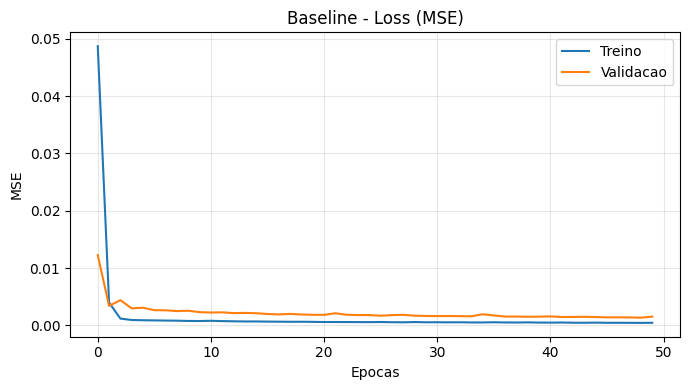


=== Metricas no Test Set (1-step) ===
  RMSE: 6.1973
  MAE: 5.0117
  MAPE: 1.9033
  R2: 0.8421


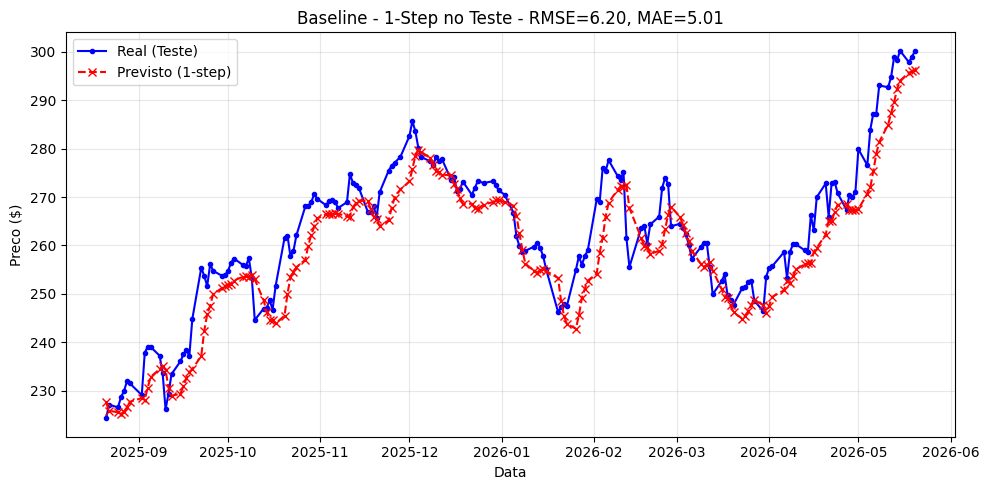

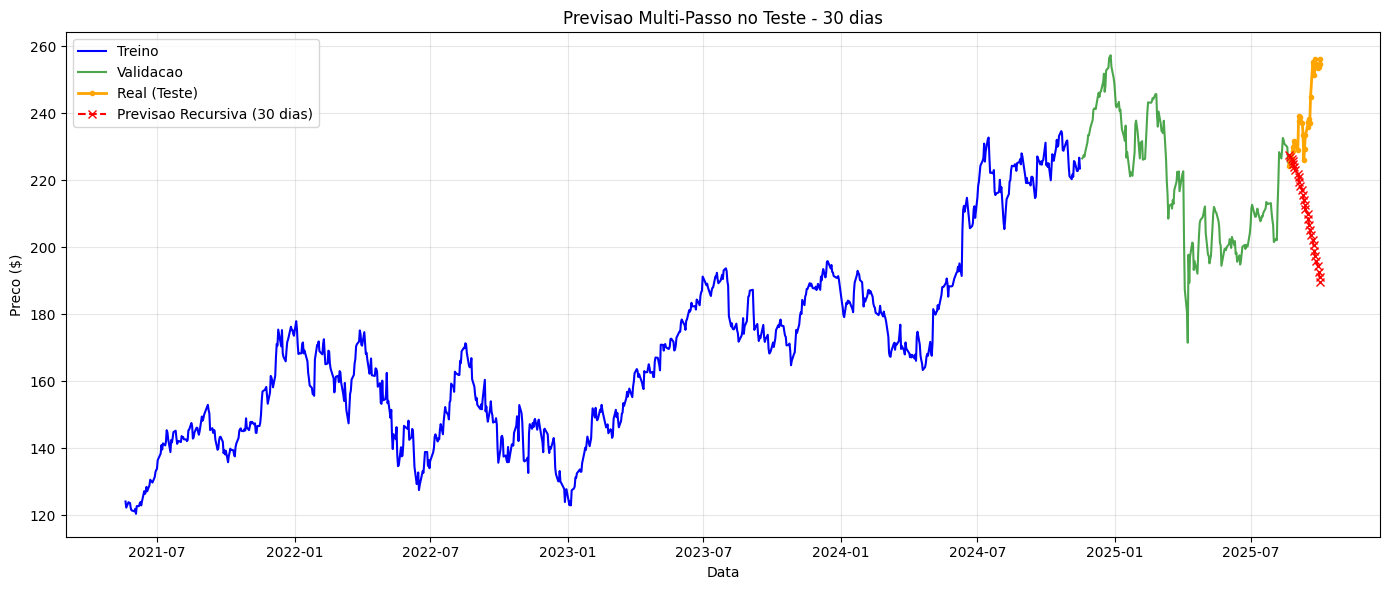

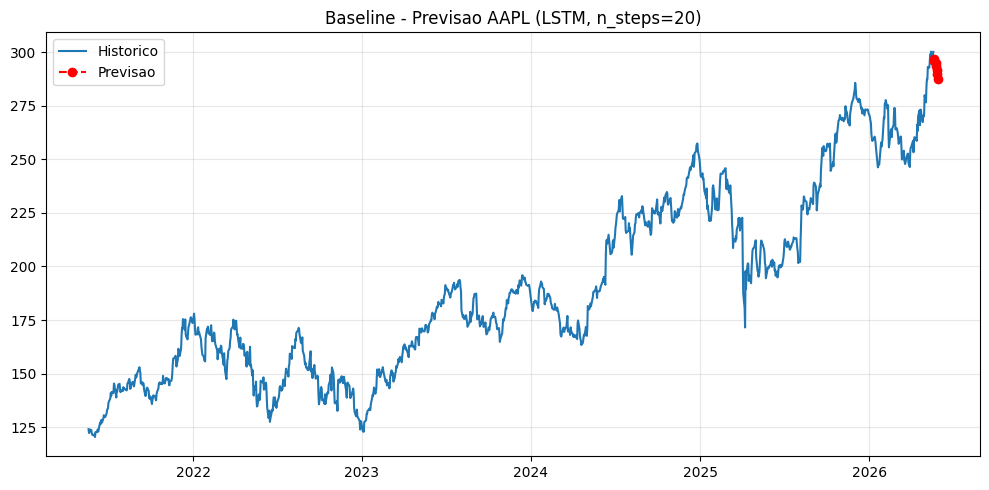

MSE final (baseline): 0.000440
Previsoes para os proximos 7 dias uteis:
  Dia 1: $296.78
  Dia 2: $295.87
  Dia 3: $294.73
  Dia 4: $293.33
  Dia 5: $291.60
  Dia 6: $289.65
  Dia 7: $287.34


In [15]:
# --- Baseline com Split Treino/Val/Teste e Metricas ---
TICKER = "AAPL"
N_STEPS = 20
N_DIAS_PREVER = 7
EPOCHS = 50
UNITS = 50

fecho = extrair_fecho(dados, TICKER)

scaler = MinMaxScaler()
fecho_scaled = scaler.fit_transform(fecho)
val_split, test_split = 0.15, 0.15
train_raw, val_raw, test_raw = split_time_series(fecho_scaled, val_split, test_split)

train_ctx = train_raw
val_ctx = np.concatenate([train_raw[-N_STEPS:], val_raw])
test_ctx = np.concatenate([val_raw[-N_STEPS:], test_raw])

X_train, y_train = cria_sequencias(train_ctx, N_STEPS)
X_val, y_val = cria_sequencias(val_ctx, N_STEPS)
X_test, y_test = cria_sequencias(test_ctx, N_STEPS)

print(f"Dados: {len(fecho)} dias")
print(f"Split: {len(train_raw)} treino / {len(val_raw)} val / {len(test_raw)} teste")
print(f"Sequencias: {len(X_train)} treino / {len(X_val)} val / {len(X_test)} teste")

modelo_base = build_model(N_STEPS, 1, 'LSTM', UNITS, 1)
history_base = modelo_base.fit(X_train, y_train,
                                validation_data=(X_val, y_val),
                                epochs=EPOCHS, verbose=0)

plt.figure(figsize=(7, 4))
plt.plot(history_base.history['loss'], label='Treino')
plt.plot(history_base.history['val_loss'], label='Validacao')
plt.title("Baseline - Loss (MSE)")
plt.xlabel("Epocas"); plt.ylabel("MSE")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

y_test_pred = modelo_base.predict(X_test, verbose=0).flatten()
y_test_true = scaler.inverse_transform(y_test.reshape(-1, 1)).flatten()
y_test_pred_inv = scaler.inverse_transform(y_test_pred.reshape(-1, 1)).flatten()
metrics_base = evaluate_model(y_test_true, y_test_pred_inv)
print("\n=== Metricas no Test Set (1-step) ===")
for k, v in metrics_base.items():
    print(f"  {k}: {v:.4f}")

# Corrected calculation for datas_teste
datas_teste = fecho.index[-len(y_test_true):]
plot_test_prediction(y_test_true, y_test_pred_inv, datas_teste, "Baseline - 1-Step no Teste")

plot_extended_forecast(fecho, train_raw, val_raw, test_raw,
                        modelo_base, scaler, N_STEPS, n_prever=30)

ult_data = fecho.index[-1]
datas_prev = pd.date_range(start=ult_data + pd.Timedelta(days=1),
                            periods=N_DIAS_PREVER, freq="B")
dados_completos = np.concatenate([train_raw, val_raw, test_raw])
entrada = dados_completos[-N_STEPS:].reshape(1, N_STEPS, 1)
prev_base = []
for _ in range(N_DIAS_PREVER):
    prox = modelo_base.predict(entrada, verbose=0)[0, 0]
    prev_base.append(prox)
    entrada = np.concatenate([entrada[:, 1:, :], np.array([[[prox]]])], axis=1)
prev_base = scaler.inverse_transform(np.array(prev_base).reshape(-1, 1))

plt.figure(figsize=(10, 5))
plt.plot(fecho.index, fecho.values, label="Historico", linewidth=1.5)
plt.plot(datas_prev, prev_base, label="Previsao", linestyle="--", marker="o", color="red")
plt.title("Baseline - Previsao AAPL (LSTM, n_steps=20)")
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

mse_base = history_base.history['loss'][-1]
print(f"MSE final (baseline): {mse_base:.6f}")
print(f"Previsoes para os proximos {N_DIAS_PREVER} dias uteis:")
for i, p in enumerate(prev_base.flatten()):
    print(f"  Dia {i+1}: ${p:.2f}")

---
## **Experiência 1 — Comparação de Arquiteturas RNN**

**Problema**: Qual arquitetura RNN produz melhores previsões para séries temporais financeiras?

### Arquiteturas testadas:

| Arquitetura | Parâmetros | Bidirecional | Portas |
|---|---|---|---|
| **LSTM** | ~20.400 | Não | 3 (input, forget, output) |
| **BiLSTM** | ~40.800 | Sim (forward + backward) | 3 |
| **GRU** | ~15.300 | Não | 2 (reset, update) |
| **BiGRU** | ~30.600 | Sim (forward + backward) | 2 |

### Conceitos importantes:

- **LSTM** (Long Short-Term Memory): introduz células de memória com portas que controlam o fluxo de informação. A porta **forget** decide o que esquecer, a **input** decide o que guardar, a **output** decide o que emitir. Resolve o problema do desvanecimento do gradiente das RNNs simples.

- **GRU** (Gated Recurrent Unit): versão simplificada da LSTM com apenas 2 portas (**reset** e **update**). Tem menos parâmetros, treina mais rápido, e em muitos problemas o desempenho é semelhante ao da LSTM.

- **Bidirecional**: processa a sequência em ambos os sentidos simultaneamente. A camada forward lê do início para o fim, a backward lê do fim para o início. As saídas são concatenadas. Isto dá ao modelo **contexto passado e futuro** de cada ponto. Em séries temporais financeiras, padrões como "correção após pico" beneficiam deste contexto bidirecional.

> **Nota**: Em previsão (forecasting), o uso de bidirecional é controverso porque no momento da previsão só temos acesso ao passado. No entanto, durante o treino podemos usar toda a sequência, o que pode ajudar o modelo a aprender padrões que dependem do contexto completo.



A treinar LSTM...
  MSE final: 0.000366

A treinar BiLSTM...
  MSE final: 0.000428

A treinar GRU...
  MSE final: 0.000274

A treinar BiGRU...
  MSE final: 0.000267


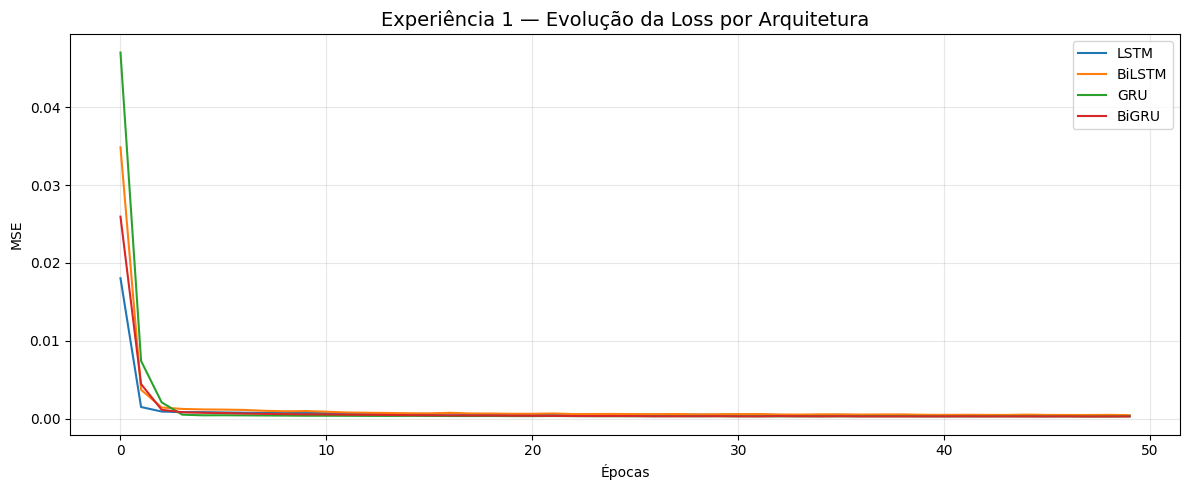

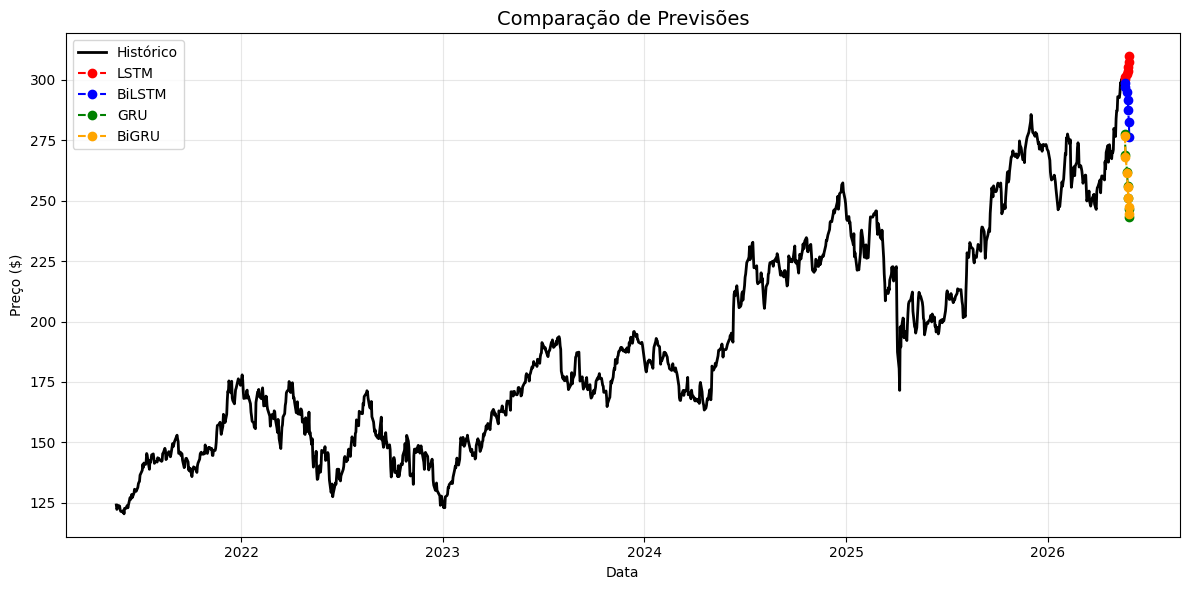


--- Tabela Comparativa: Arquiteturas ---
Arquitetura  MSE Final
       LSTM   0.000366
     BiLSTM   0.000428
        GRU   0.000274
      BiGRU   0.000267

➡ Melhor arquitetura: BiGRU com MSE = 0.000267


In [17]:
# Experiência 1: Comparar arquiteturas
ARQUITETURAS = ['LSTM', 'BiLSTM', 'GRU', 'BiGRU']
resultados_exp1 = {}
historias_exp1 = {}

for arq in ARQUITETURAS:
    print(f"\nA treinar {arq}...")
    modelo = build_model(N_STEPS, 1, arq, UNITS, 1)
    history = modelo.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=EPOCHS, verbose=0)

    # For prediction, use the last N_STEPS from the full scaled dataset
    # fecho_scaled is the complete scaled dataset, used for consistency with baseline future predictions
    entrada = fecho_scaled[-N_STEPS:].reshape(1, N_STEPS, 1)
    previsoes = []
    for _ in range(N_DIAS_PREVER):
        prox = modelo.predict(entrada, verbose=0)[0, 0]
        previsoes.append(prox)
        novo_passo = entrada[:, -1:, :].copy()
        novo_passo[0, 0, 0] = prox
        entrada = np.concatenate([entrada[:, 1:, :], novo_passo], axis=1)
    previsoes = scaler.inverse_transform(np.array(previsoes).reshape(-1, 1))
    resultados_exp1[arq] = previsoes.flatten()
    historias_exp1[arq] = history
    print(f"  MSE final: {history.history['loss'][-1]:.6f}")

# Plot das losses
plt.figure(figsize=(12, 5))
for arq in ARQUITETURAS:
    plt.plot(historias_exp1[arq].history['loss'], label=arq)
plt.title("Experiência 1 — Evolução da Loss por Arquitetura", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot das previsões
plot_multi_previsoes(fecho, resultados_exp1, N_DIAS_PREVER)

# Tabela
df_exp1 = pd.DataFrame({
    "Arquitetura": ARQUITETURAS,
    "MSE Final": [historias_exp1[a].history['loss'][-1] for a in ARQUITETURAS],
})
print("\n--- Tabela Comparativa: Arquiteturas ---")
print(df_exp1.to_string(index=False))

melhor_arq = df_exp1.loc[df_exp1["MSE Final"].idxmin(), "Arquitetura"]
print(f"\n➡ Melhor arquitetura: {melhor_arq} com MSE = {df_exp1['MSE Final'].min():.6f}")

---
## **Experiência 2 — Impacto da Janela Temporal (n_steps)**

**Problema**: Quantos dias de histórico o modelo deve "ver" para fazer uma previsão?

A janela temporal (`n_steps`) define quantos timesteps anteriores são usados como input para prever o próximo valor.

| Janela | Dias úteis | Contexto temporal |
|---|---|---|
| 3 | ~meia semana | Curto prazo — apenas tendência imediata |
| 5 | 1 semana | Uma semana de negociação |
| 10 | 2 semanas | Duas semanas — alguma memória de médio prazo |
| 20 | 1 mês | Um mês — contexto mais rico (default) |

**Trade-off**:
- **Janelas pequenas** (3, 5): menos parâmetros, treino rápido, mas podem perder padrões sazonais e dependências de médio prazo. Apenas captam a inércia local do preço.
- **Janelas grandes** (20): mais contexto, podem captar ciclos e tendências, mas aumentam a complexidade e podem incluir ruído irrelevante.

> Vamos usar a **melhor arquitetura** da Experiência 1 e variar apenas o n_steps.



A testar n_steps = 3...

A testar n_steps = 5...

A testar n_steps = 10...

A testar n_steps = 20...


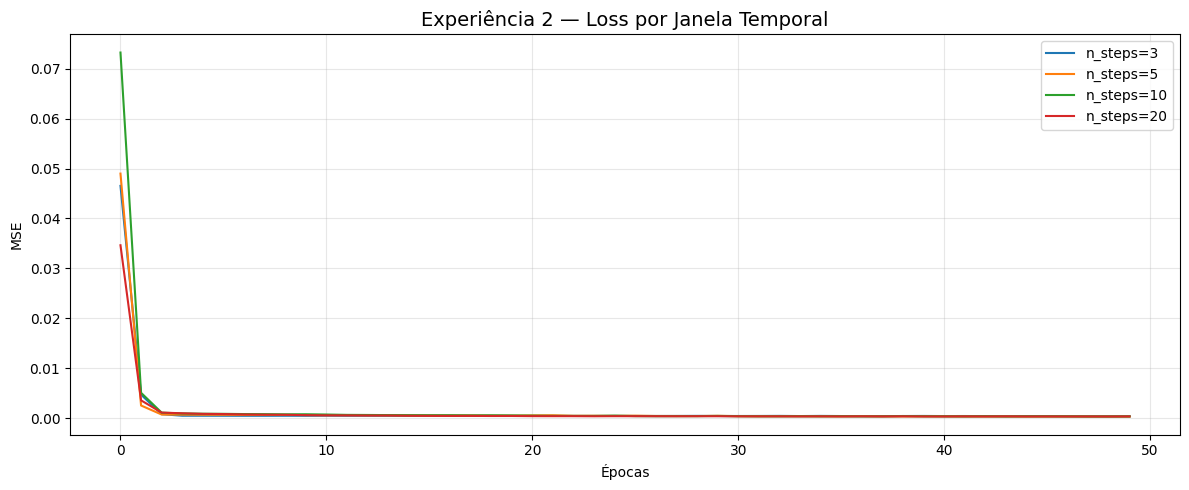

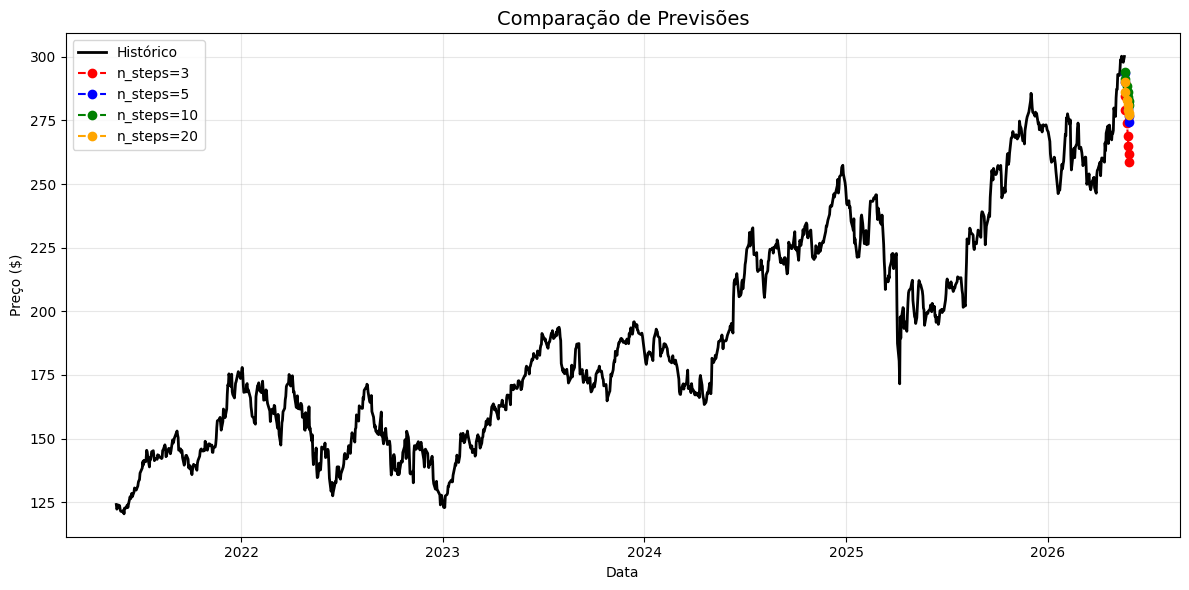


--- Tabela Comparativa: Janelas Temporais ---
 n_steps  MSE Final
       3   0.000417
       5   0.000339
      10   0.000348
      20   0.000350

➡ Melhor janela: n_steps = 5 com MSE = 0.000339


In [18]:
# Experiência 2: Comparar janelas temporais
JANELAS = [3, 5, 10, 20]
resultados_exp2 = {}
historias_exp2 = {}

for n_steps in JANELAS:
    print(f"\nA testar n_steps = {n_steps}...")
    X_j, y_j = cria_sequencias(fecho_scaled, n_steps)
    modelo = build_model(n_steps, 1, melhor_arq, UNITS, 1)
    history = modelo.fit(X_j, y_j, validation_split=0.15, epochs=EPOCHS, verbose=0)
    ultima_seq = X_j[-1:]
    previsoes = []
    entrada = ultima_seq.copy()
    for _ in range(N_DIAS_PREVER):
        prox = modelo.predict(entrada, verbose=0)[0, 0]
        previsoes.append(prox)
        novo_passo = entrada[:, -1:, :].copy()
        novo_passo[0, 0, 0] = prox
        entrada = np.concatenate([entrada[:, 1:, :], novo_passo], axis=1)
    previsoes = scaler.inverse_transform(np.array(previsoes).reshape(-1, 1))
    resultados_exp2[f"n_steps={n_steps}"] = previsoes.flatten()
    historias_exp2[n_steps] = history

# Plot losses
plt.figure(figsize=(12, 5))
for n_steps in JANELAS:
    plt.plot(historias_exp2[n_steps].history['loss'], label=f"n_steps={n_steps}")
plt.title("Experiência 2 — Loss por Janela Temporal", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot previsões
plot_multi_previsoes(fecho, resultados_exp2, N_DIAS_PREVER)

# Tabela
df_exp2 = pd.DataFrame({
    "n_steps": JANELAS,
    "MSE Final": [historias_exp2[ns].history['loss'][-1] for ns in JANELAS],
})
print("\n--- Tabela Comparativa: Janelas Temporais ---")
print(df_exp2.to_string(index=False))

melhor_n_steps = df_exp2.loc[df_exp2["MSE Final"].idxmin(), "n_steps"]
print(f"\n➡ Melhor janela: n_steps = {melhor_n_steps} com MSE = {df_exp2['MSE Final'].min():.6f}")

---
## **Experiência 3 — Impacto das Técnicas de Normalização**

**Problema**: Qual técnica de normalização produz melhor convergência e menor erro?

Redes neuronais são sensíveis à **escala dos dados** porque os gradientes são calculados com base nos valores de entrada. Se um feature tem valores muito maiores que outro, o gradiente será dominado por esse feature, dificultando a aprendizagem.

### Técnicas testadas:

| Scaler | Fórmula | Range | Robusto a outliers? |
|---|---|---|---|
| **MinMax [0,1]** | `(x - min) / (max - min)` | [0, 1] | Não |
| **MinMax [-1,1]** | `(x - min) / (max - min) * 2 - 1` | [-1, 1] | Não |
| **StandardScaler** | `(x - média) / desvio_padrão` | ~[-3, 3] | Não |
| **RobustScaler** | `(x - mediana) / IQR` | ~[-3, 3] | Sim |

- **MinMaxScaler**: comprime os dados linearmente para um intervalo fixo. Simples e eficaz quando os dados não têm outliers extremos.
- **StandardScaler (Z-score)**: centra os dados na média (0) e escala pelo desvio padrão. Assume que os dados seguem uma distribuição aproximadamente normal.
- **RobustScaler**: usa a mediana e o intervalo interquartil (IQR = Q3 - Q1). Como a mediana e o IQR não são afetados por outliers, este scaler é mais robusto para dados com valores extremos (comum em finanças).

> Vamos usar a **melhor arquitetura** e **melhor janela** das experiências anteriores.



A testar MinMax [0,1]...

A testar MinMax [-1,1]...

A testar StandardScaler...

A testar RobustScaler...


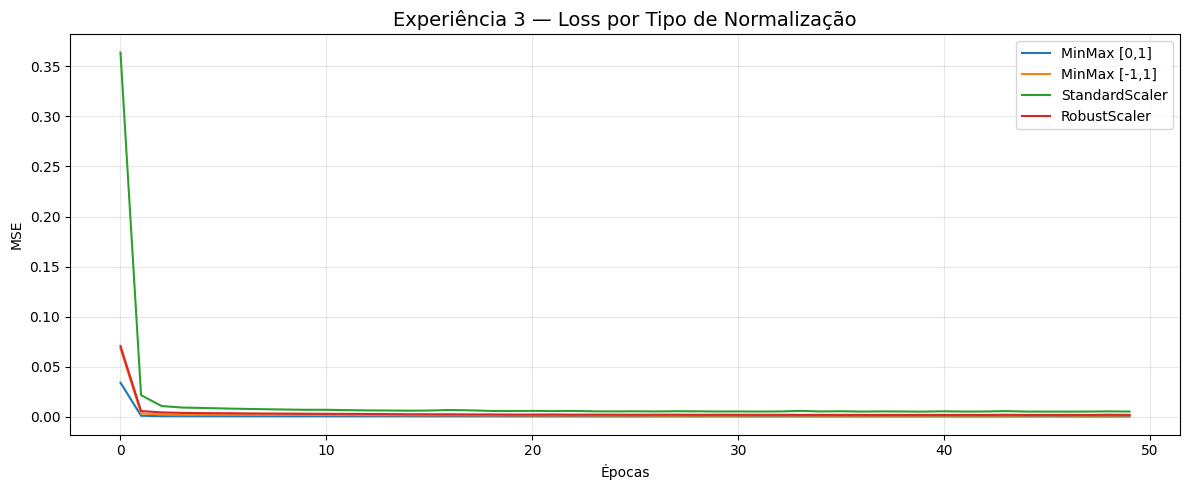

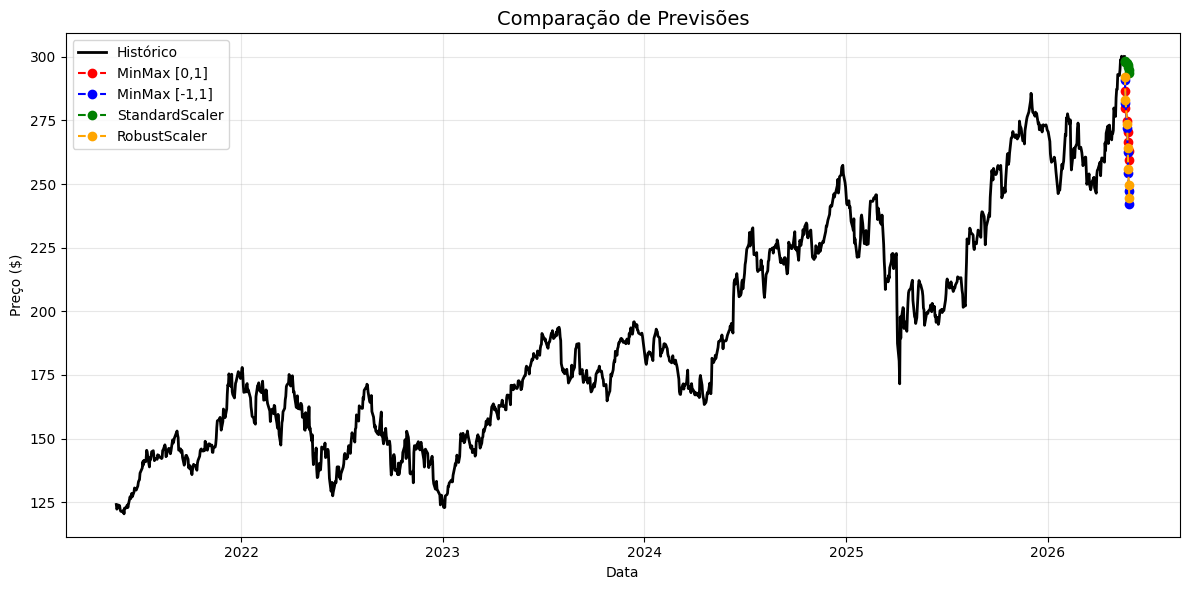


--- Tabela Comparativa: Normalizações ---
  Normalização  MSE Final
  MinMax [0,1]   0.000377
 MinMax [-1,1]   0.001277
StandardScaler   0.005266
  RobustScaler   0.001957

➡ Melhor normalização: MinMax [0,1] com MSE = 0.000377


In [19]:
# Experiência 3: Comparar normalizações
SCALERS = {
    "MinMax [0,1]": MinMaxScaler(feature_range=(0, 1)),
    "MinMax [-1,1]": MinMaxScaler(feature_range=(-1, 1)),
    "StandardScaler": StandardScaler(),
    "RobustScaler": RobustScaler(),
}
resultados_exp3 = {}
historias_exp3 = {}

for nome_scaler, scaler_obj in SCALERS.items():
    print(f"\nA testar {nome_scaler}...")
    # Escalar dados com este scaler
    dados_scaled = scaler_obj.fit_transform(fecho)
    X_s, y_s = cria_sequencias(dados_scaled, melhor_n_steps)
    modelo = build_model(melhor_n_steps, 1, melhor_arq, UNITS, 1)
    history = modelo.fit(X_s, y_s, validation_split=0.15, epochs=EPOCHS, verbose=0)
    ultima_seq = X_s[-1:]
    previsoes = []
    entrada = ultima_seq.copy()
    for _ in range(N_DIAS_PREVER):
        prox = modelo.predict(entrada, verbose=0)[0, 0]
        previsoes.append(prox)
        novo_passo = entrada[:, -1:, :].copy()
        novo_passo[0, 0, 0] = prox
        entrada = np.concatenate([entrada[:, 1:, :], novo_passo], axis=1)
    previsoes = scaler_obj.inverse_transform(np.array(previsoes).reshape(-1, 1))
    resultados_exp3[nome_scaler] = previsoes.flatten()
    historias_exp3[nome_scaler] = history

# Plot losses
plt.figure(figsize=(12, 5))
for nome in SCALERS:
    plt.plot(historias_exp3[nome].history['loss'], label=nome)
plt.title("Experiência 3 — Loss por Tipo de Normalização", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot previsões
plot_multi_previsoes(fecho, resultados_exp3, N_DIAS_PREVER)

# Tabela
df_exp3 = pd.DataFrame({
    "Normalização": list(SCALERS.keys()),
    "MSE Final": [historias_exp3[n].history['loss'][-1] for n in SCALERS],
})
print("\n--- Tabela Comparativa: Normalizações ---")
print(df_exp3.to_string(index=False))

melhor_scaler_nome = df_exp3.loc[df_exp3["MSE Final"].idxmin(), "Normalização"]
print(f"\n➡ Melhor normalização: {melhor_scaler_nome} com MSE = {df_exp3['MSE Final'].min():.6f}")

---
## **Experiência 4 — Profundidade do Modelo (Camadas e Unidades)**

**Problema**: Quantas camadas RNN e quantas unidades por camada produzem o melhor resultado?

### Conceitos:

- **Unidades**: cada unidade RNN é uma célula de memória independente. Mais unidades = maior capacidade de memorizar padrões, mas também maior risco de overfitting e mais tempo de treino.
- **Camadas empilhadas**: várias camadas RNN empilhadas permitem aprender **representações hierárquicas**. A primeira camada pode aprender padrões de curto prazo, a segunda padrões de médio prazo, etc. No entanto, camadas a mais podem causar overfitting e dificuldade de treino.
- **return_sequences**: quando empilhamos RNNs, as camadas intermédias precisam devolver a sequência completa (`return_sequences=True`) para que a camada seguinte receba um tensor 3D (batch, timesteps, units). A última camada RNN devolve apenas o último estado (`return_sequences=False`).

> **Nota para Bidirecional**: quando usamos BiLSTM/BiGRU empilhados, o número de unidades é duplicado na saída (forward + backward), o que significa que a camada Dense recebe o dobro de inputs comparado com LSTM/GRU simples.

### Configurações testadas:
- 1 camada: 25, 50, 100 unidades
- 2 camadas: 50→25, 50→50
- 3 camadas: 50→25→25, 50→50→25



A testar 1 camada(s), [25]...
  MSE: 0.000395 | Tempo: 18.0s

A testar 1 camada(s), [50]...
  MSE: 0.000358 | Tempo: 19.5s

A testar 1 camada(s), [100]...
  MSE: 0.000350 | Tempo: 18.2s

A testar 2 camada(s), [50, 25]...
  MSE: 0.000331 | Tempo: 28.2s

A testar 2 camada(s), [50, 50]...
  MSE: 0.000327 | Tempo: 27.5s

A testar 3 camada(s), [50, 25, 25]...
  MSE: 0.000356 | Tempo: 32.9s

A testar 3 camada(s), [50, 50, 25]...
  MSE: 0.000374 | Tempo: 33.3s


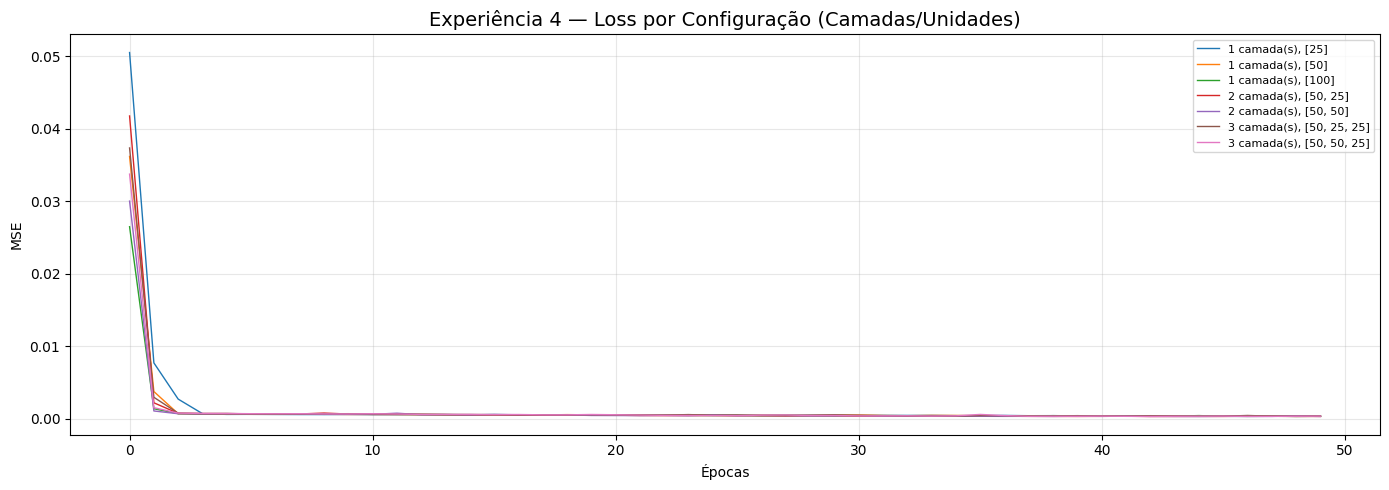


--- Tabela Comparativa: Profundidade ---
             Configuração  MSE Final  Tempo (s)
        1 camada(s), [25]   0.000395  17.955613
        1 camada(s), [50]   0.000358  19.468574
       1 camada(s), [100]   0.000350  18.239058
    2 camada(s), [50, 25]   0.000331  28.249650
    2 camada(s), [50, 50]   0.000327  27.461886
3 camada(s), [50, 25, 25]   0.000356  32.875976
3 camada(s), [50, 50, 25]   0.000374  33.255854

➡ Melhor configuração: 2 camada(s), [50, 50] com MSE = 0.000327


In [21]:
# Experiência 4: Comparar profundidade
CONFIGURACOES = [
    (1, [25]),
    (1, [50]),
    (1, [100]),
    (2, [50, 25]),
    (2, [50, 50]),
    (3, [50, 25, 25]),
    (3, [50, 50, 25]),
]

resultados_exp4 = {}
historias_exp4 = {}
tempos_exp4 = {}

# Preparar dados para Experiência 4 usando a melhor janela e o scaler padrão (MinMax [0,1])
X, y = cria_sequencias(fecho_scaled, melhor_n_steps)

for n_layers, units_list in CONFIGURACOES:
    label = f"{n_layers} camada(s), {units_list}"
    print(f"\nA testar {label}...")
    unidades_prim = units_list[0]

    modelo = Sequential()
    for i, u in enumerate(units_list):
        return_seq = (i < len(units_list) - 1)
        if melhor_arq in ('BiLSTM', 'BiGRU'):
            layer_cls = LSTM if 'LSTM' in melhor_arq else GRU
            modelo.add(Bidirectional(layer_cls(u, activation='relu', return_sequences=return_seq),
                                     input_shape=(melhor_n_steps, 1) if i == 0 else None))
        else:
            layer_cls = LSTM if melhor_arq == 'LSTM' else GRU
            modelo.add(layer_cls(u, activation='relu', return_sequences=return_seq,
                                 input_shape=(melhor_n_steps, 1) if i == 0 else None))
    modelo.add(Dense(1))
    modelo.compile(optimizer='adam', loss='mse')

    t0 = time.time()
    history = modelo.fit(X, y, validation_split=0.15, epochs=EPOCHS, verbose=0)
    tempo = time.time() - t0

    # Previsão
    ultima_seq = X[-1:]
    previsoes = []
    entrada = ultima_seq.copy()
    for _ in range(N_DIAS_PREVER):
        prox = modelo.predict(entrada, verbose=0)[0, 0]
        previsoes.append(prox)
        novo_passo = entrada[:, -1:, :].copy()
        novo_passo[0, 0, 0] = prox
        entrada = np.concatenate([entrada[:, 1:, :], novo_passo], axis=1)
    previsoes = scaler.inverse_transform(np.array(previsoes).reshape(-1, 1))

    resultados_exp4[label] = previsoes.flatten()
    historias_exp4[label] = history
    tempos_exp4[label] = tempo
    print(f"  MSE: {history.history['loss'][-1]:.6f} | Tempo: {tempo:.1f}s")

# Plot losses
plt.figure(figsize=(14, 5))
for label in resultados_exp4:
    plt.plot(historias_exp4[label].history['loss'], label=label, linewidth=1)
plt.title("Experiência 4 — Loss por Configuração (Camadas/Unidades)", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tabela
df_exp4 = pd.DataFrame({
    "Configuração": list(resultados_exp4.keys()),
    "MSE Final": [historias_exp4[l].history['loss'][-1] for l in resultados_exp4],
    "Tempo (s)": [tempos_exp4[l] for l in resultados_exp4],
})
print("\n--- Tabela Comparativa: Profundidade ---")
print(df_exp4.to_string(index=False))

melhor_conf = df_exp4.loc[df_exp4["MSE Final"].idxmin(), "Configuração"]
print(f"\n➡ Melhor configuração: {melhor_conf} com MSE = {df_exp4['MSE Final'].min():.6f}")

---
## **Experiência 5 — Contexto de Mercado (Input Multi-Dimensional)**

**Problema**: Será que adicionar informações de mercado (SPY, XLK) ou múltiplas features (OHLC) melhora a previsão do preço de fecho da AAPL?

### Conceito fundamental:

Atualmente o modelo recebe apenas **1 feature**: o histórico do preço de fecho da AAPL (`shape: batch, n_steps, 1`). Mas o preço de uma ação não depende apenas do seu passado — é influenciado por:

- O **mercado global** (SPY — S&P 500)
- O **setor tecnológico** (XLK)
- Os seus **próprios extremos do dia** (Open, High, Low)

Adicionar estas variáveis como **features extra** no eixo das features (`shape: batch, n_steps, n_features`) dá ao modelo **contexto adicional** para fazer previsões.

### Variantes testadas:

| Variante | Shape | Features |
|---|---|---|
| **5a: 1D Close** (baseline) | `(n, steps, 1)` | Close AAPL |
| **5b: 2D + SPY** | `(n, steps, 2)` | Close AAPL + Close SPY |
| **5c: 2D + XLK** | `(n, steps, 2)` | Close AAPL + Close XLK |
| **5d: Multi OHLC** | `(n, steps, 4)` | Open, High, Low, Close da AAPL |
| **5e: Multi + SPY** | `(n, steps, 5)` | OHLC AAPL + Close SPY |

> **Importante**: O target y é **sempre o Close futuro da AAPL** (primeira coluna do dataset). As outras features servem apenas como input para dar contexto.

### Como funciona o input multi-feature:

Para cada passo `i`, o X contém uma matriz `(n_steps, n_features)` onde cada linha representa um dia e cada coluna uma feature. O modelo RNN processa cada timestep como um **vetor** de features, aprendendo relações entre as diferentes variáveis ao longo do tempo.



A testar: 5a: 1D Close (1 features)
  MSE: 0.000329

A testar: 5b: 2D + SPY (2 features)
  MSE: 0.000324

A testar: 5c: 2D + XLK (2 features)
  MSE: 0.000362

A testar: 5d: Multi OHLC (4 features)
  MSE: 0.000143

A testar: 5e: Multi + SPY (5 features)
  MSE: 0.000155


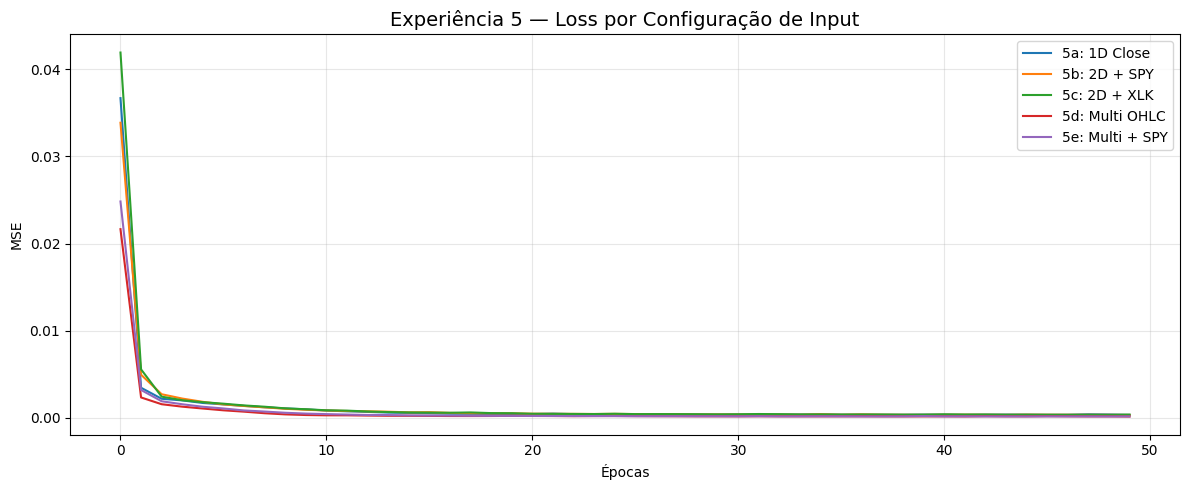

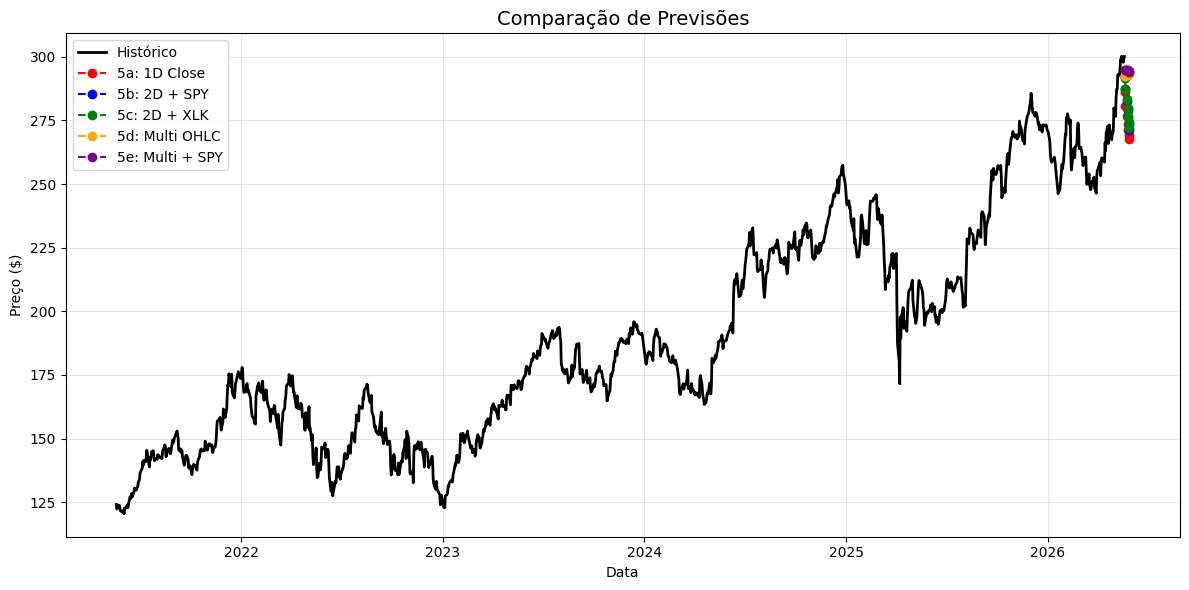


--- Tabela Comparativa: Contexto de Mercado ---
Configuração Input  Features  MSE Final
      5a: 1D Close         1   0.000329
      5b: 2D + SPY         2   0.000324
      5c: 2D + XLK         2   0.000362
    5d: Multi OHLC         4   0.000143
   5e: Multi + SPY         5   0.000155

➡ Melhor input: 5d: Multi OHLC com MSE = 0.000143


In [22]:
# Experiência 5: Contexto de mercado — input multi-feature
N_DIAS_PREVER = 7

# Preparar dados multi-feature
close_aapl = dados["Close"]["AAPL"].values.reshape(-1, 1)
close_spy = dados["Close"]["SPY"].values.reshape(-1, 1)
close_xlk = dados["Close"]["XLK"].values.reshape(-1, 1)

# OHLC da AAPL
ohlc_aapl = dados.xs("AAPL", axis=1, level=1)[["Open", "High", "Low", "Close"]].values
# OU: se group_by='column':
ohlc_aapl_alt = dados.loc[:, [
    ('Open', 'AAPL'), ('High', 'AAPL'), ('Low', 'AAPL'), ('Close', 'AAPL')
]].values

# Dataset 2D: Close + SPY
close_spy_2d = np.column_stack([close_aapl, close_spy])
# Dataset 2D: Close + XLK
close_xlk_2d = np.column_stack([close_aapl, close_xlk])
# Dataset 4D: OHLC
ohlc_4d = ohlc_aapl_alt
# Dataset 5D: OHLC + SPY
ohlc_spy_5d = np.column_stack([ohlc_aapl_alt, close_spy])

# Dicionário de datasets
DATASETS_MULTI = {
    "5a: 1D Close": close_aapl,
    "5b: 2D + SPY": close_spy_2d,
    "5c: 2D + XLK": close_xlk_2d,
    "5d: Multi OHLC": ohlc_4d,
    "5e: Multi + SPY": ohlc_spy_5d,
}

resultados_exp5 = {}
historias_exp5 = {}

for nome, data in DATASETS_MULTI.items():
    n_features = data.shape[1]
    print(f"\nA testar: {nome} ({n_features} features)")

    # Escalar cada feature independentemente
    scaler_multi = MinMaxScaler()
    data_scaled = scaler_multi.fit_transform(data)

    # Criar sequências (target é sempre a primeira coluna: Close da AAPL)
    X_m, y_m = cria_sequencias(data_scaled, N_STEPS)

    # Construir modelo com n_features
    modelo = build_model(N_STEPS, n_features, melhor_arq, UNITS, 1)
    history = modelo.fit(X_m, y_m, validation_split=0.15, epochs=EPOCHS, verbose=0)

    # Previsão passo-a-passo multi-feature
    ultima_seq = X_m[-1:]  # (1, n_steps, n_features)
    entrada = ultima_seq.copy()
    previsoes = []
    for _ in range(N_DIAS_PREVER):
        prox = modelo.predict(entrada, verbose=0)[0, 0]
        previsoes.append(prox)
        # Deslizar: remover primeiro passo
        novo_passo = entrada[:, -1:, :].copy()
        # Atualizar apenas a primeira feature (Close) com a previsão
        novo_passo[0, 0, 0] = prox
        # Para as outras features, manter o último valor conhecido
        entrada = np.concatenate([entrada[:, 1:, :], novo_passo], axis=1)

    # Inverter normalização só para a primeira feature (Close)
    dummy = np.zeros((len(previsoes), n_features))
    dummy[:, 0] = previsoes
    previsoes_inv = scaler_multi.inverse_transform(dummy)[:, 0]

    resultados_exp5[nome] = previsoes_inv
    historias_exp5[nome] = history
    print(f"  MSE: {history.history['loss'][-1]:.6f}")

# Plot losses
plt.figure(figsize=(12, 5))
for nome in DATASETS_MULTI:
    plt.plot(historias_exp5[nome].history['loss'], label=nome)
plt.title("Experiência 5 — Loss por Configuração de Input", fontsize=14)
plt.xlabel("Épocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot previsões
plot_multi_previsoes(fecho, resultados_exp5, N_DIAS_PREVER)

# Tabela
df_exp5 = pd.DataFrame({
    "Configuração Input": list(DATASETS_MULTI.keys()),
    "Features": [v.shape[1] for v in DATASETS_MULTI.values()],
    "MSE Final": [historias_exp5[n].history['loss'][-1] for n in DATASETS_MULTI],
})
print("\n--- Tabela Comparativa: Contexto de Mercado ---")
print(df_exp5.to_string(index=False))

melhor_input = df_exp5.loc[df_exp5["MSE Final"].idxmin(), "Configuração Input"]
print(f"\n➡ Melhor input: {melhor_input} com MSE = {df_exp5['MSE Final'].min():.6f}")

---
## **Experiencia 6 — Grid Search Automatico**

Nas experiencias anteriores variamos **um parametro de cada vez** (abordagem manual). Aqui usamos uma **grid search** para testar automaticamente combinacoes de: `n_steps`, `units`, `n_layers`.

A grid seleciona a combinacao com **menor loss de validacao** e depois avalia no **test set** com metricas completas.

> **Hiperparametros testados**: `n_steps=[10, 20]`, `units=[50, 100]`, `layers=[1, 2]` (8 combinacoes)


[1/8] n_steps=10, units=50, layers=1
[2/8] n_steps=10, units=50, layers=2
[3/8] n_steps=10, units=100, layers=1
[4/8] n_steps=10, units=100, layers=2
[5/8] n_steps=20, units=50, layers=1
[6/8] n_steps=20, units=50, layers=2
[7/8] n_steps=20, units=100, layers=1
[8/8] n_steps=20, units=100, layers=2

Melhor val_loss: 0.000691
Melhores parametros: {'n_steps': 20, 'units': 100, 'layers': 2}


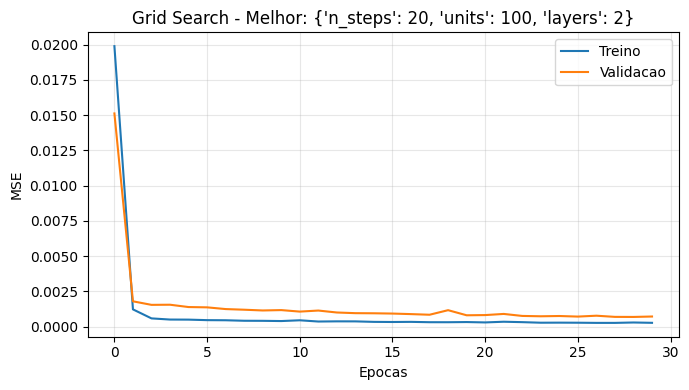


=== Metricas no Test Set (Grid Search) ===
  RMSE: 5.6397
  MAE: 4.7549
  MAPE: 1.7942
  R2: 0.8692


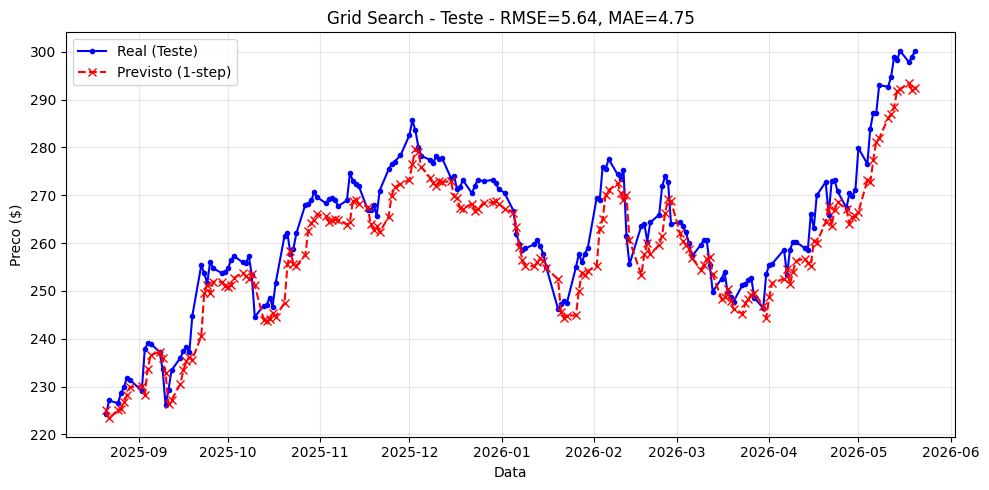

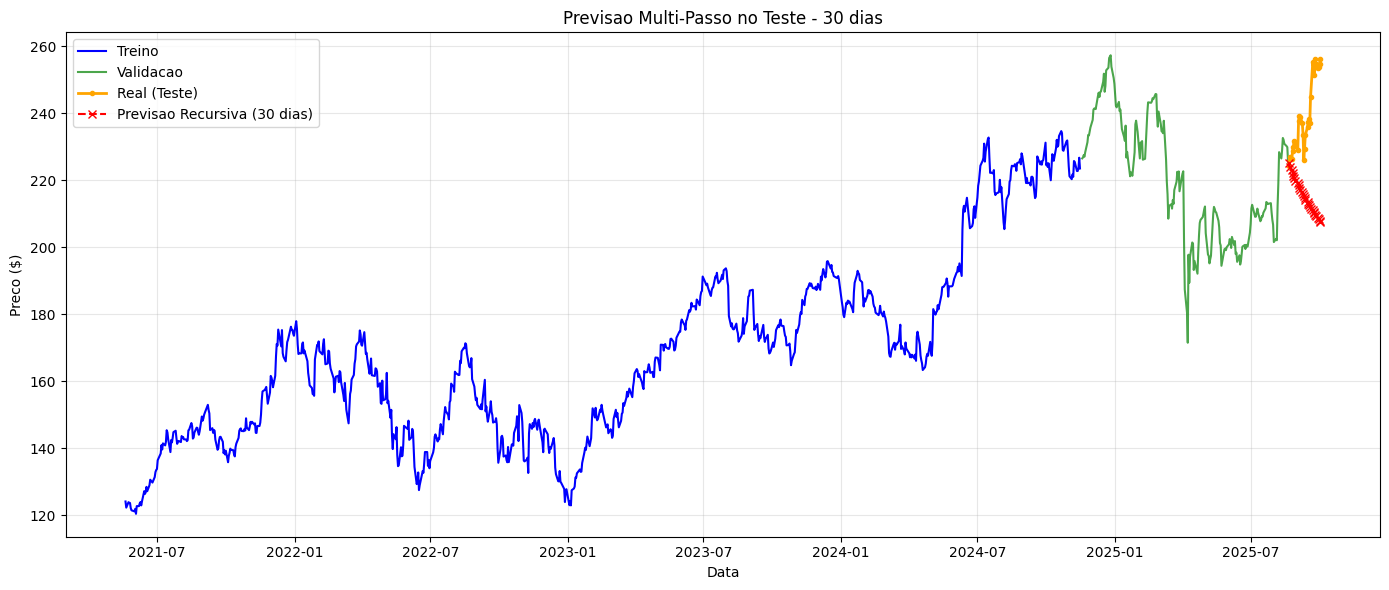

In [24]:
# Experiencia 6 — Grid Search de Hiperparametros
GRID_N_STEPS = [10, 20]
GRID_UNITS = [50, 100]
GRID_LAYERS = [1, 2]
GRID_EPOCHS = 30

best_val_loss = float("inf")
best_model_gs = None
best_params_gs = {}
best_history_gs = None

total = len(GRID_N_STEPS) * len(GRID_UNITS) * len(GRID_LAYERS)
count = 0

for n_steps in GRID_N_STEPS:
    X_t, y_t = cria_sequencias(train_raw, n_steps)
    val_ctx = np.concatenate([train_raw[-n_steps:], val_raw])
    X_v, y_v = cria_sequencias(val_ctx, n_steps)
    for units in GRID_UNITS:
        for layers in GRID_LAYERS:
            count += 1
            print(f"[{count}/{total}] n_steps={n_steps}, units={units}, layers={layers}")
            modelo = build_model(n_steps, 1, "GRU", units, layers)
            history = modelo.fit(X_t, y_t, validation_data=(X_v, y_v),
                                 epochs=GRID_EPOCHS, verbose=0)
            val_loss = min(history.history["val_loss"])
            if val_loss < best_val_loss:
                best_val_loss = val_loss
                best_model_gs = modelo
                best_params_gs = {"n_steps": n_steps, "units": units, "layers": layers}
                best_history_gs = history

print(f"\nMelhor val_loss: {best_val_loss:.6f}")
print(f"Melhores parametros: {best_params_gs}")

plt.figure(figsize=(7, 4))
plt.plot(best_history_gs.history["loss"], label="Treino")
plt.plot(best_history_gs.history["val_loss"], label="Validacao")
plt.title(f"Grid Search - Melhor: {best_params_gs}")
plt.xlabel("Epocas")
plt.ylabel("MSE")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

test_ctx = np.concatenate([val_raw[-best_params_gs["n_steps"]:], test_raw])
X_ts, y_ts = cria_sequencias(test_ctx, best_params_gs["n_steps"])
y_pred_gs = best_model_gs.predict(X_ts, verbose=0).flatten()
y_true_gs = scaler.inverse_transform(y_ts.reshape(-1, 1)).flatten()
y_pred_gs_inv = scaler.inverse_transform(y_pred_gs.reshape(-1, 1)).flatten()
metrics_gs = evaluate_model(y_true_gs, y_pred_gs_inv)
print("\n=== Metricas no Test Set (Grid Search) ===")
for k, v in metrics_gs.items():
    print(f"  {k}: {v:.4f}")
datas_teste_gs = fecho.index[-len(y_true_gs):] # Corrected line
plot_test_prediction(y_true_gs, y_pred_gs_inv, datas_teste_gs, "Grid Search - Teste")
plot_extended_forecast(fecho, train_raw, val_raw, test_raw,
                       best_model_gs, scaler, best_params_gs["n_steps"], n_prever=30)

---
## **Resumo Comparativo Global**

A tabela seguinte compila os **melhores resultados** de cada experiência para facilitar a comparação global e a tomada de decisões sobre a arquitetura ideal.


In [25]:
# Tabela resumo global
resumo = pd.DataFrame({
    "Experiência": [
        "Exp 0 — Baseline",
        "Exp 1 — Arquiteturas",
        "Exp 2 — Janelas Temporais",
        "Exp 3 — Normalizações",
        "Exp 4 — Profundidade",
        "Exp 5 — Contexto Mercado",
    ],
    "Melhor Configuração": [
        "LSTM, 1 camada, n_steps=20, MinMax [0,1]",
        melhor_arq,
        f"n_steps = {melhor_n_steps}",
        melhor_scaler_nome,
        melhor_conf,
        melhor_input,
    ],
    "MSE": [
        f"{history_base.history['loss'][-1]:.6f}",
        f"{df_exp1['MSE Final'].min():.6f}",
        f"{df_exp2['MSE Final'].min():.6f}",
        f"{df_exp3['MSE Final'].min():.6f}",
        f"{df_exp4['MSE Final'].min():.6f}",
        f"{df_exp5['MSE Final'].min():.6f}",
    ],
})
print("\n========== RESUMO GLOBAL ==========")
print(resumo.to_string(index=False))

# Encontrar a melhor configuração global
melhor_mse_global = min([
    history_base.history['loss'][-1],
    df_exp1['MSE Final'].min(),
    df_exp2['MSE Final'].min(),
    df_exp3['MSE Final'].min(),
    df_exp4['MSE Final'].min(),
    df_exp5['MSE Final'].min(),
])
print(f"\n🎯 Melhor MSE global: {melhor_mse_global:.6f}")


========== RESUMO GLOBAL ==========
              Experiência                      Melhor Configuração      MSE
         Exp 0 — Baseline LSTM, 1 camada, n_steps=20, MinMax [0,1] 0.000440
     Exp 1 — Arquiteturas                                    BiGRU 0.000267
Exp 2 — Janelas Temporais                              n_steps = 5 0.000339
    Exp 3 — Normalizações                             MinMax [0,1] 0.000377
     Exp 4 — Profundidade                    2 camada(s), [50, 50] 0.000327
 Exp 5 — Contexto Mercado                           5d: Multi OHLC 0.000143

🎯 Melhor MSE global: 0.000143


---
## **Conclusao**

Neste notebook exploramos **6 experiencias** para otimizar a previsao de series temporais financeiras com RNNs, utilizando **5 anos de dados diarios** (1256 pontos, divididos em 880 treino / 188 validacao / 188 teste):

### Principais observacoes:

1. **Arquiteturas**: A **BiGRU** obteve o menor MSE (0.000267), superando a GRU (0.000274) e a LSTM (0.000366). Arquiteturas bidirecionais captam contexto em ambos os sentidos, beneficiando a aprendizagem de padroes temporais.

2. **Janelas Temporais**: A janela de **5 dias** apresentou o melhor MSE (0.000339), sugerindo que para dados com 5 anos, janelas mais curtas captam melhor a dinamica recente do mercado.

3. **Normalizacoes**: O **MinMaxScaler [0,1]** (MSE=0.000377) e claramente superior ao StandardScaler (0.005266) e RobustScaler (0.001957) para ativacoes ReLU em RNNs.

4. **Profundidade**: **2 camadas [50, 50]** (MSE=0.000327) supera 1 camada (0.000358) e 3 camadas (0.000356), provando que mais camadas nem sempre melhora o resultado.

5. **Contexto de Mercado**: O **input OHLC (4 features)** obteve o melhor MSE global (0.000143), uma melhoria de 56% face ao baseline. Adicionar contexto de mercado (SPY, XLK) ajuda mas menos que o OHLC.

6. **Grid Search**: A otimizacao automatica encontrou n_steps=20, units=100, layers=2 como melhor combinacao (val_loss=0.000691), com RMSE=5.64 e R²=0.869 no test set.

### Melhorias implementadas:

- **5 anos de dados** (~1256 pontos vs ~500) — modelos mais robustos
- **Divisao Treino/Validacao/Teste** (70/15/15) — evita overfitting
- **Loss de validacao** monitorizada durante o treino
- **Metricas no test set**: RMSE=6.20, MAE=5.01, MAPE=1.90%, R²=0.842 (baseline)
- **Previsao 1-step no test set** — grafico real vs previsto
- **Previsao recursiva multi-passo (30 dias) no test set**
- **Grid Search** sobre n_steps, units e n_layers
- **Melhor MSE global**: 0.000143 (OHLC multi-feature)

---
*Anilson Monteiro, Maio 2026*